
# Financial Risk Classification  
### Logistic Regression, KNN, and Naive Bayes  




## 1. Import Required Libraries


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


import warnings
warnings.filterwarnings('ignore')


## 2. Load Dataset


In [ ]:

df = pd.read_csv("/content/Financial Risk Classification Dataset.csv")
df.head()


,age,annual_income,education_years,work_experience_years,credit_score,loan_amount,loan_duration_months,interest_rate,debt_to_income_ratio,monthly_expenses,...,marital_status_score,health_risk_index,insurance_coverage_score,spending_score,online_activity_score,device_usage_hours,location_risk_index,previous_default_count,financial_literacy_score,loan_default
0,19,51140.401281,10,21,724.748104,3899.654973,60,9.577176,0.733655,2704.161100,...,3,0.692560,3,68,12,7.289109,0.540080,1,68,0
1,24,69028.631473,8,19,655.666339,21084.032813,48,8.383830,0.798551,2611.106393,...,1,0.469194,3,62,5,5.108674,0.007390,0,92,0
2,44,55186.372954,10,1,821.874508,28297.796011,24,7.321765,0.454056,2442.756164,...,1,0.001102,2,20,16,2.906073,0.704191,1,52,0
3,31,61403.651502,12,16,715.445294,38358.635271,12,5.997473,0.579187,2369.382349,...,2,0.753590,2,65,80,2.938127,0.701259,0,88,0
4,31,42536.559850,9,19,850.000000,46599.675272,36,9.115591,0.135722,2052.929537,...,1,0.364849,5,98,96,5.440193,0.524457,0,58,0



## 3. Dataset Overview


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         5000 non-null   int64  
 1   annual_income               5000 non-null   float64
 2   education_years             5000 non-null   int64  
 3   work_experience_years       5000 non-null   int64  
 4   credit_score                5000 non-null   float64
 5   loan_amount                 5000 non-null   float64
 6   loan_duration_months        5000 non-null   int64  
 7   interest_rate               5000 non-null   float64
 8   debt_to_income_ratio        5000 non-null   float64
 9   monthly_expenses            5000 non-null   float64
 10  savings_balance             5000 non-null   float64
 11  investment_balance          5000 non-null   float64
 12  number_of_dependents        5000 non-null   int64  
 13  employment_stability_years  5000 

In [ ]:

df.describe()


,age,annual_income,education_years,work_experience_years,credit_score,loan_amount,loan_duration_months,interest_rate,debt_to_income_ratio,monthly_expenses,...,marital_status_score,health_risk_index,insurance_coverage_score,spending_score,online_activity_score,device_usage_hours,location_risk_index,previous_default_count,financial_literacy_score,loan_default
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,41.013800,60165.316248,13.492600,19.54480,679.749638,25017.723237,36.07680,10.498878,0.474845,2491.020854,...,1.992600,0.499794,2.971000,50.523600,50.706400,6.226375,0.505953,0.484000,50.869800,0.000200
std,13.451669,15144.023201,3.448525,11.44873,58.926659,11758.762374,17.13929,4.333477,0.247662,799.721575,...,0.816504,0.291004,1.404049,28.741932,28.474739,3.319219,0.289312,0.692994,28.795901,0.014142
min,18.000000,15000.000000,8.000000,0.00000,472.273265,1000.000000,12.00000,3.007391,0.050072,300.000000,...,1.000000,0.000084,1.000000,1.000000,1.000000,0.502232,0.000068,0.000000,1.000000,0.000000
25%,29.000000,49760.711426,10.000000,10.00000,638.926975,16893.125095,24.00000,6.803467,0.259268,1949.191002,...,1.000000,0.239153,2.000000,26.000000,26.000000,3.351673,0.250350,0.000000,26.000000,0.000000
50%,41.000000,60079.300451,13.000000,20.00000,679.377059,24665.287323,36.00000,10.469467,0.476113,2477.942181,...,2.000000,0.508279,3.000000,50.000000,51.000000,6.184174,0.510482,0.000000,51.000000,0.000000
75%,53.000000,70323.447053,17.000000,29.00000,719.961457,33099.337250,48.00000,14.267566,0.689688,3032.498218,...,3.000000,0.749022,4.000000,75.000000,75.000000,9.080226,0.754968,1.000000,76.000000,0.000000
max,64.000000,124279.331912,19.000000,39.00000,850.000000,65468.608043,60.00000,17.996729,0.899764,5295.999796,...,3.000000,0.999784,5.000000,100.000000,100.000000,11.997336,0.999952,5.000000,100.000000,1.000000



## 4. Feature–Target Split


In [ ]:

X = df.drop("loan_default", axis=1)
y = df["loan_default"]



## 5. Train-Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)



## 6. Feature Scaling


In [ ]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## 7. Logistic Regression Model


In [ ]:

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1250

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250




## 8. K-Nearest Neighbors (KNN)


In [ ]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1250

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250




## 9. Naive Bayes (Gaussian)


In [ ]:

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred_nb = nb_model.predict(X_test_scaled)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1250

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250




## 10. Confusion Matrix Visualization


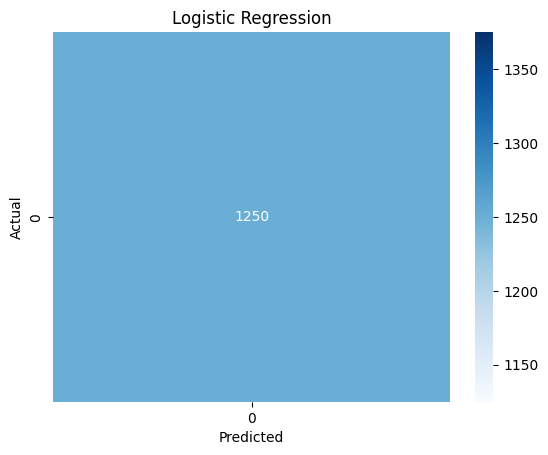

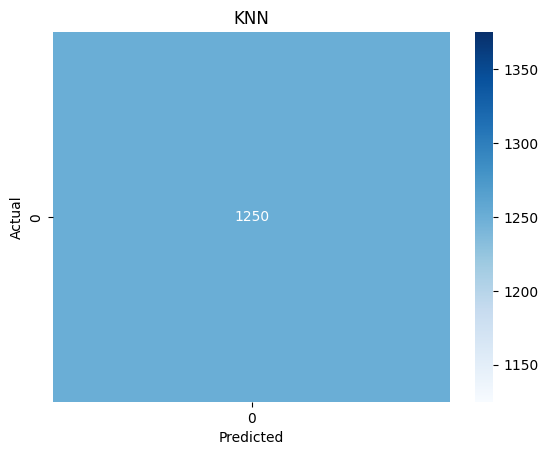

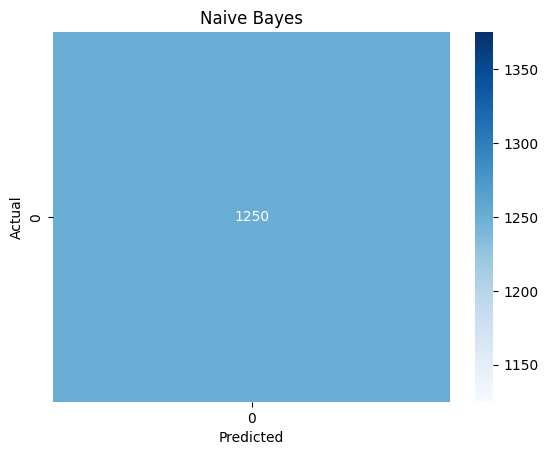

In [ ]:

models = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb
}

for model_name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(model_name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()




- Logistic Regression performs well on linearly separable data.
- KNN captures local patterns.
- Naive Bayes is fast and effective for Gaussian features.

